In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from model.model import Autoencoder

In [9]:
batch_size = 64
learning_rate = 1e-3
num_epochs = 10
latent_dim = 64

device = "cpu"

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [10]:
model = Autoencoder(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [11]:
def vae_loss_function(reconstructed, original, mu, log_var, kl_weight=0.5):
    # Reconstruction loss
    recon_loss = nn.BCELoss(reduction='sum')(reconstructed, original.view(original.size(0), -1))
    
    # KL divergence
    kl_div = -kl_weight * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return recon_loss + kl_div, recon_loss, kl_div

In [12]:
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_recon_loss = 0.0
    epoch_kl_div = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        reconstructed, mu, log_var = model(data)

        loss, recon_loss, kl_div = vae_loss_function(reconstructed, data, mu, log_var, 1.0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kl_div += kl_div.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}, Recon Loss: {epoch_recon_loss/len(train_loader):.4f}, KL Div: {epoch_kl_div/len(train_loader):.4f}")

torch.save(model.state_dict(), "model/autoencoder_mnist.pth")

print("Training complete!")


Epoch [1/10], Loss: 12098.7734, Recon Loss: 11545.8344, KL Div: 552.9389
Epoch [2/10], Loss: 9590.3999, Recon Loss: 8463.4035, KL Div: 1126.9964
Epoch [3/10], Loss: 8938.7440, Recon Loss: 7667.3144, KL Div: 1271.4297
Epoch [4/10], Loss: 8610.8362, Recon Loss: 7251.2105, KL Div: 1359.6257
Epoch [5/10], Loss: 8445.7643, Recon Loss: 7031.8276, KL Div: 1413.9367
Epoch [6/10], Loss: 8306.0222, Recon Loss: 6844.5776, KL Div: 1461.4446
Epoch [7/10], Loss: 8210.8299, Recon Loss: 6713.5577, KL Div: 1497.2722
Epoch [8/10], Loss: 8140.1767, Recon Loss: 6622.8886, KL Div: 1517.2881
Epoch [9/10], Loss: 8084.3794, Recon Loss: 6549.4296, KL Div: 1534.9498
Epoch [10/10], Loss: 8045.8375, Recon Loss: 6495.5292, KL Div: 1550.3083
Training complete!


/tmp/ipykernel_148941/1731909859.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


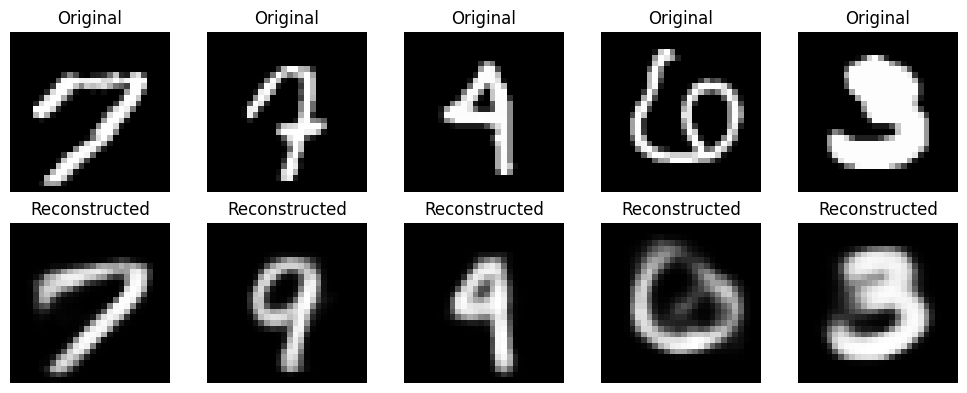

In [16]:
def visualize_reconstructions(model_path, num_images=5):
    model = Autoencoder(latent_dim).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=num_images, shuffle=True)

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            outputs, mu, log_var = model(data)

            # Plot original and reconstructed images
            fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
            for i in range(num_images):
                # Original images
                axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
                axes[0, i].axis('off')
                axes[0, i].set_title("Original")

                # Reconstructed images
                axes[1, i].imshow(outputs[i].cpu().view(28, 28), cmap='gray')
                axes[1, i].axis('off')
                axes[1, i].set_title("Reconstructed")
            break

    plt.tight_layout()
    plt.show()

# Visualize some reconstructions
visualize_reconstructions("model/autoencoder_mnist.pth", num_images=5)